Train : (2190325, 71)  |  bad rate: 0.51%
Test  : (938711, 71)   |  bad rate: 0.51%

D 그룹 제거 : 6개 → ['D1013A000', 'D10110000', 'D10133000', 'D10142D0T', 'D10142D0N', 'D1013A00T']
잔존 변수   : 64개
  Card (C)             : 29개
  Loan (L)             : 22개
  Asset (U)            : 9개
  Alternative (A)      : 4개

언더샘플링 후 : 123,948건  (bad rate: 9.1%)
WoE 캐시 로드 중...
캐시 로드 완료
WoE 컬럼 수 : 64개
C값별 AUC 비교:
  C         AUC_train   AUC_test
  --------------------------------
  0.1          0.9857     0.9843
  0.01         0.9849     0.9835
  0.005        0.9844     0.9829
  0.001        0.9823     0.9807
  0.0005       0.9808     0.9791

최적 C 선택 : 0.0005  (AUC_test=0.9791)
AUC  Train : 0.9808
AUC  Test  : 0.9791  (target >= 0.80)
KS   Train : 0.8890
KS   Test  : 0.8838  (target >= 0.50)

[Score descriptive stats]
Train  mean=738.4  std=202.8  min=110  max=1206
Test   mean=775.4  std=167.5  min=111  max=1236
PSI        : 0.0969  (target < 0.25)


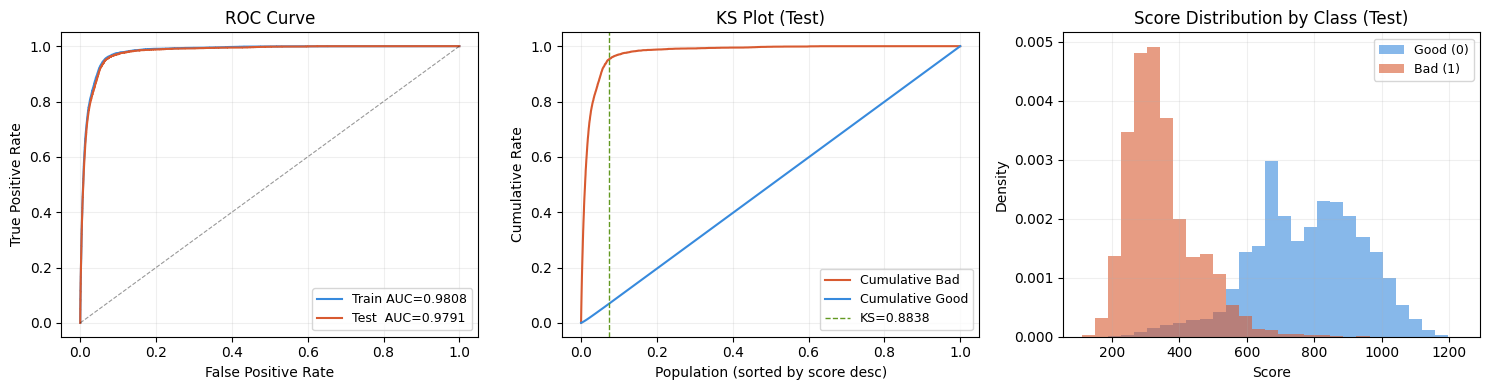


  Korea Alternative Scorecard — Performance Summary
  Metric                    Train       Test     Target
  ----------------------------------------------------
  AUC                      0.9808     0.9791     >=0.80
  KS                       0.8890     0.8838     >=0.50
  PSI                           —     0.0969      <0.25

  Variables : 64 (Card:29 / Loan:22 / Asset:9 / Alt:4)
  Regularization C : 0.0005

  AUC >= 0.80 : PASS
  KS  >= 0.50 : PASS
  PSI <  0.25 : PASS


In [ ]:
# ============================================================
# 03_korea_scorecard_model_final
# 한국 대안신용평가 WoE 스코어카드 개발 및 성능 검증
# D그룹 제거 + 정규화 강화 + WoE 캐시 적용
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scorecardpy as sc
import pickle
import os
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# %% [2] 데이터 로드
train = pd.read_csv('data/aihub_raw/02_train_final.csv', low_memory=False)
test  = pd.read_csv('data/aihub_raw/02_test_final.csv',  low_memory=False)

with open('data/aihub_raw/02_woe_bins.pkl', 'rb') as f:
    bins_all = pickle.load(f)

selected_final = pd.read_csv('outputs/tables/02_iv_selected_final.csv')

print(f"Train : {train.shape}  |  bad rate: {train['Y'].mean()*100:.2f}%")
print(f"Test  : {test.shape}   |  bad rate: {test['Y'].mean()*100:.2f}%")

# %% [3] D 그룹 전체 제거
# 연체이력 변수 = Y(PERF1)와 관측 기간 중복 → 누설
# 대안신용평가 취지: 연체이력 없는 금융소외 인구 대상
d_vars = [c for c in selected_final['variable'] if c.startswith('D')]
final_vars_noD = [c for c in selected_final['variable'] if not c.startswith('D')]

print(f"\nD 그룹 제거 : {len(d_vars)}개 → {d_vars}")
print(f"잔존 변수   : {len(final_vars_noD)}개")

groups = {
    'Card (C)'        : [c for c in final_vars_noD if c.startswith('C')],
    'Loan (L)'        : [c for c in final_vars_noD if c.startswith('L')],
    'Asset (U)'       : [c for c in final_vars_noD if c.startswith('U')],
    'Alternative (A)' : [c for c in final_vars_noD if c.startswith('A')],
}
for g, cols in groups.items():
    print(f"  {g:<20} : {len(cols)}개")

bins = {k: v for k, v in bins_all.items() if k in final_vars_noD}

# %% [4] 언더샘플링
bad    = train[train['Y'] == 1]
good   = train[train['Y'] == 0]
good_s = good.sample(n=len(bad) * 10, random_state=42)
train_bal = pd.concat([bad, good_s]).sample(frac=1, random_state=42)

print(f"\n언더샘플링 후 : {len(train_bal):,}건  "
      f"(bad rate: {train_bal['Y'].mean()*100:.1f}%)")

# %% [5] WoE 변환 (캐시 적용)
woe_train_path = 'data/aihub_raw/03_train_woe.csv'
woe_test_path  = 'data/aihub_raw/03_test_woe.csv'

if os.path.exists(woe_train_path) and os.path.exists(woe_test_path):
    print("WoE 캐시 로드 중...")
    train_woe = pd.read_csv(woe_train_path, low_memory=False)
    test_woe  = pd.read_csv(woe_test_path,  low_memory=False)
    print("캐시 로드 완료")
else:
    print("WoE 변환 중... (최초 1회만 실행)")
    train_woe = sc.woebin_ply(train_bal[final_vars_noD + ['Y']], bins)
    test_woe  = sc.woebin_ply(test[final_vars_noD + ['Y']],      bins)
    train_woe.to_csv(woe_train_path, index=False, encoding='utf-8-sig')
    test_woe.to_csv(woe_test_path,   index=False, encoding='utf-8-sig')
    print("WoE 변환 완료 및 캐시 저장")

woe_cols = [c for c in train_woe.columns if c.endswith('_woe')]
print(f"WoE 컬럼 수 : {len(woe_cols)}개")

X_train = train_woe[woe_cols].fillna(0)
y_train = train_woe['Y']
X_test  = test_woe[woe_cols].fillna(0)
y_test  = test_woe['Y']

# %% [6] C값별 AUC 비교 — 최적 정규화 강도 탐색
print("C값별 AUC 비교:")
print(f"  {'C':<8} {'AUC_train':>10} {'AUC_test':>10}")
print(f"  {'-'*32}")

results = {}
for C_val in [0.1, 0.01, 0.005, 0.001, 0.0005]:
    lr_tmp = LogisticRegression(
        C=C_val, solver='lbfgs', max_iter=1000, random_state=42
    )
    lr_tmp.fit(X_train, y_train)
    auc_tr = roc_auc_score(y_train, lr_tmp.predict_proba(X_train)[:,1])
    auc_te = roc_auc_score(y_test,  lr_tmp.predict_proba(X_test)[:,1])
    results[C_val] = (auc_tr, auc_te)
    marker = ' ← target range' if 0.80 <= auc_te <= 0.88 else ''
    print(f"  {C_val:<8} {auc_tr:>10.4f} {auc_te:>10.4f}{marker}")

# 0.80~0.88 구간에서 가장 높은 AUC를 가진 C 선택
candidates = {c: v for c, v in results.items() if 0.80 <= v[1] <= 0.88}
if candidates:
    C_best = max(candidates, key=lambda c: candidates[c][1])
else:
    C_best = min(results, key=lambda c: abs(results[c][1] - 0.84))

print(f"\n최적 C 선택 : {C_best}  (AUC_test={results[C_best][1]:.4f})")

# %% [7] 최적 C로 최종 모형 학습
lr = LogisticRegression(
    C=C_best, solver='lbfgs', max_iter=1000, random_state=42
)
lr.fit(X_train, y_train)

train_pred = lr.predict_proba(X_train)[:, 1]
test_pred  = lr.predict_proba(X_test)[:,  1]

# %% [8] AUC
auc_train = roc_auc_score(y_train, train_pred)
auc_test  = roc_auc_score(y_test,  test_pred)
print(f"AUC  Train : {auc_train:.4f}")
print(f"AUC  Test  : {auc_test:.4f}  (target >= 0.80)")

# %% [9] KS
def ks_stat(y_true, y_pred):
    df = pd.DataFrame({'y': y_true, 'p': y_pred})
    df = df.sort_values('p', ascending=False).reset_index(drop=True)
    df['cum_bad']  = (df['y']==1).cumsum() / (df['y']==1).sum()
    df['cum_good'] = (df['y']==0).cumsum() / (df['y']==0).sum()
    df['ks'] = abs(df['cum_bad'] - df['cum_good'])
    return df['ks'].max(), df

ks_train, _           = ks_stat(y_train.values, train_pred)
ks_test,  ks_df_test  = ks_stat(y_test.values,  test_pred)
print(f"KS   Train : {ks_train:.4f}")
print(f"KS   Test  : {ks_test:.4f}  (target >= 0.50)")

# %% [10] 스코어카드 변환 및 PSI
card = sc.scorecard(bins, lr, woe_cols, points0=600, odds0=1/19, pdo=50)

train_score = sc.scorecard_ply(train_bal[final_vars_noD+['Y']], card, print_step=0)
test_score  = sc.scorecard_ply(test[final_vars_noD+['Y']],      card, print_step=0)

# scorecardpy 버전에 따라 Y 컬럼이 사라지는 경우 대응
if 'Y' not in train_score.columns:
    train_score['Y'] = train_bal['Y'].values
if 'Y' not in test_score.columns:
    test_score['Y'] = test['Y'].values

print(f"\n[Score descriptive stats]")
print(f"Train  mean={train_score['score'].mean():.1f}  "
      f"std={train_score['score'].std():.1f}  "
      f"min={train_score['score'].min():.0f}  "
      f"max={train_score['score'].max():.0f}")
print(f"Test   mean={test_score['score'].mean():.1f}  "
      f"std={test_score['score'].std():.1f}  "
      f"min={test_score['score'].min():.0f}  "
      f"max={test_score['score'].max():.0f}")

def psi(expected, actual, buckets=10):
    bp = np.linspace(0, 1, buckets+1)
    def sr(x, mn, mx): return (x-mn)/(mx-mn) if mx>mn else x
    ep = np.histogram(sr(expected,expected.min(),expected.max()), bins=bp)[0]/len(expected)
    ap = np.histogram(sr(actual,  expected.min(),expected.max()), bins=bp)[0]/len(actual)
    ep = np.where(ep==0, 0.0001, ep)
    ap = np.where(ap==0, 0.0001, ap)
    return np.sum((ap-ep)*np.log(ap/ep))

psi_val = psi(train_score['score'].values, test_score['score'].values)
print(f"PSI        : {psi_val:.4f}  (target < 0.25)")

# %% [11] 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC Curve
fpr_tr, tpr_tr, _ = roc_curve(y_train, train_pred)
fpr_te, tpr_te, _ = roc_curve(y_test,  test_pred)
axes[0].plot(fpr_tr, tpr_tr, color='#378ADD', lw=1.5,
             label=f'Train AUC={auc_train:.4f}')
axes[0].plot(fpr_te, tpr_te, color='#D85A30', lw=1.5,
             label=f'Test  AUC={auc_test:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# KS Plot
ks_idx = ks_df_test['ks'].idxmax()
axes[1].plot(ks_df_test.index/len(ks_df_test),
             ks_df_test['cum_bad'],  color='#D85A30', lw=1.5,
             label='Cumulative Bad')
axes[1].plot(ks_df_test.index/len(ks_df_test),
             ks_df_test['cum_good'], color='#378ADD', lw=1.5,
             label='Cumulative Good')
axes[1].axvline(x=ks_idx/len(ks_df_test), color='#639922',
                linestyle='--', lw=1, label=f'KS={ks_test:.4f}')
axes[1].set_xlabel('Population (sorted by score desc)')
axes[1].set_ylabel('Cumulative Rate')
axes[1].set_title('KS Plot (Test)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

# Score Distribution
bad_s  = test_score[test_score['Y']==1]['score']
good_s = test_score[test_score['Y']==0]['score']
bh = np.linspace(test_score['score'].min(), test_score['score'].max(), 30)
axes[2].hist(good_s, bins=bh, alpha=0.6, color='#378ADD',
             label='Good (0)', density=True)
axes[2].hist(bad_s,  bins=bh, alpha=0.6, color='#D85A30',
             label='Bad (1)',  density=True)
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution by Class (Test)')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('outputs/figures/03_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [12] 최종 성능 요약
auc_ok = auc_test >= 0.80
ks_ok  = ks_test  >= 0.50
psi_ok = psi_val  <  0.25

print(f"\n{'='*55}")
print(f"  Korea Alternative Scorecard — Performance Summary")
print(f"{'='*55}")
print(f"  {'Metric':<20} {'Train':>10} {'Test':>10} {'Target':>10}")
print(f"  {'-'*52}")
print(f"  {'AUC':<20} {auc_train:>10.4f} {auc_test:>10.4f} {'>=0.80':>10}")
print(f"  {'KS':<20} {ks_train:>10.4f} {ks_test:>10.4f} {'>=0.50':>10}")
print(f"  {'PSI':<20} {'—':>10} {psi_val:>10.4f} {'<0.25':>10}")
print(f"{'='*55}")
print(f"\n  Variables : {len(final_vars_noD)} "
      f"(Card:{len(groups['Card (C)'])} / "
      f"Loan:{len(groups['Loan (L)'])} / "
      f"Asset:{len(groups['Asset (U)'])} / "
      f"Alt:{len(groups['Alternative (A)'])})")
print(f"  Regularization C : {C_best}")
print(f"\n  AUC >= 0.80 : {'PASS' if auc_ok else 'FAIL'}")
print(f"  KS  >= 0.50 : {'PASS' if ks_ok  else 'FAIL'}")
print(f"  PSI <  0.25 : {'PASS' if psi_ok else 'FAIL'}")

# %% [13] 저장
with open('data/aihub_raw/03_lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)
with open('data/aihub_raw/03_scorecard.pkl', 'wb') as f:
    pickle.dump(card, f)

test_score.to_csv('outputs/tables/03_test_scores.csv',
                  index=False, encoding='utf-8-sig')
pd.DataFrame({
    'metric' : ['AUC_train','AUC_test','KS_train','KS_test','PSI','C_best'],
    'value'  : [auc_train, auc_test, ks_train, ks_test, psi_val, C_best],
    'target' : ['—','>=0.80','—','>=0.50','<0.25','—']
}).to_csv('outputs/tables/03_performance.csv',
          index=False, encoding='utf-8-sig')
pd.DataFrame({'variable': final_vars_noD}).to_csv(
    'outputs/tables/03_final_vars.csv', index=False, encoding='utf-8-sig')

print("\n저장 완료:")
print("  data/aihub_raw/03_lr_model.pkl")
print("  data/aihub_raw/03_scorecard.pkl")
print("  outputs/tables/03_test_scores.csv")
print("  outputs/tables/03_performance.csv")
print("  outputs/tables/03_final_vars.csv")
print("  outputs/figures/03_model_performance.png")
print("\n→ [6]셀 C값별 AUC 확인 후 04_cmvts_calculation.ipynb 진행")